# 03 — LSTM Model (Global)

**Strategiya:**
- Bitta global LSTM barcha 20 filialga
- Branch embedding orqali har filialning xususiyati o'rgatiladi
- Input: oxirgi 20 ish kuni balansi + kalendar feature'lar + branch_id
- Output: keyingi 7 ish kuni balansi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from time import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [2]:
data = pd.read_csv('../data/synthetic_data.csv', parse_dates=['date'])
branches_df = pd.read_csv('../data/branches.csv')
data = data.sort_values(['branch_id', 'date']).reset_index(drop=True)
print(f'{len(data):,} qator, {data["branch_id"].nunique()} filial')

10,200 qator, 20 filial


In [3]:
SEQ_LEN = 20        # oxirgi 20 ish kuni (~1 oy)
PRED_LEN = 7        # keyingi 7 ish kuni (Prophet bilan bir xil)
TEST_DAYS = 7
BATCH_SIZE = 64
EPOCHS = 50
LR = 0.001
HIDDEN = 64
EMB_DIM = 8
NUM_BRANCHES = data['branch_id'].nunique()

FEATURES = ['day_of_week', 'day_of_month', 'month', 'is_payday', 'is_ramadan', 'is_pre_holiday']
print(f'Sequence: {SEQ_LEN} -> {PRED_LEN}')
print(f'Features: {FEATURES}')

Sequence: 20 -> 7
Features: ['day_of_week', 'day_of_month', 'month', 'is_payday', 'is_ramadan', 'is_pre_holiday']


In [4]:
all_dates = sorted(data['date'].unique())
split_date = pd.to_datetime(all_dates[-TEST_DAYS - 1])
train_data = data[data['date'] <= split_date].copy()
test_data = data[data['date'] > split_date].copy()

balance_scaler = StandardScaler()
train_data['balance_scaled'] = balance_scaler.fit_transform(train_data[['balance']])
test_data['balance_scaled'] = balance_scaler.transform(test_data[['balance']])

feature_scaler = StandardScaler()
train_data[FEATURES] = feature_scaler.fit_transform(train_data[FEATURES])
test_data[FEATURES] = feature_scaler.transform(test_data[FEATURES])

print(f'Train: {len(train_data)} qator')
print(f'Test:  {len(test_data)} qator')

Train: 10060 qator
Test:  140 qator


In [5]:
class CashDataset(Dataset):
    def __init__(self, df, seq_len, pred_len, features):
        X_seq, X_feat, y, branch_ids = [], [], [], []
        
        for bid, group in df.groupby('branch_id'):
            group = group.sort_values('date').reset_index(drop=True)
            balances = group['balance_scaled'].values
            feats = group[features].values
            
            n = len(group)
            for i in range(n - seq_len - pred_len + 1):
                X_seq.append(balances[i:i + seq_len])
                X_feat.append(feats[i:i + seq_len])
                y.append(balances[i + seq_len:i + seq_len + pred_len])
                branch_ids.append(bid - 1)
        
        X_seq = torch.tensor(np.array(X_seq), dtype=torch.float32).unsqueeze(-1)
        X_feat = torch.tensor(np.array(X_feat), dtype=torch.float32)
        self.X = torch.cat([X_seq, X_feat], dim=-1)
        self.y = torch.tensor(np.array(y), dtype=torch.float32)
        self.branch_ids = torch.tensor(branch_ids, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.branch_ids[idx], self.y[idx]


train_dataset = CashDataset(train_data, SEQ_LEN, PRED_LEN, FEATURES)
INPUT_SIZE = train_dataset.X.shape[-1]
print(f'Train sequences: {len(train_dataset)}')
print(f'Input shape: {train_dataset.X[0].shape}, input_size={INPUT_SIZE}')

Train sequences: 9540
Input shape: torch.Size([20, 7]), input_size=7


In [6]:
def make_test_samples(train_data, test_data, seq_len, features, pred_len):
    X_test, branch_test, y_test, dates_test = [], [], [], []
    
    for bid in train_data['branch_id'].unique():
        train_b = train_data[train_data['branch_id'] == bid].sort_values('date')
        test_b = test_data[test_data['branch_id'] == bid].sort_values('date')
        
        last_balance = train_b['balance_scaled'].values[-seq_len:]
        last_feat = train_b[features].values[-seq_len:]
        seq = np.concatenate([last_balance.reshape(-1, 1), last_feat], axis=1)
        target = test_b['balance_scaled'].values[:pred_len]
        
        if len(target) == pred_len:
            X_test.append(seq)
            branch_test.append(bid - 1)
            y_test.append(target)
            dates_test.append(test_b['date'].values[:pred_len])
    
    return (
        torch.tensor(np.array(X_test), dtype=torch.float32),
        torch.tensor(branch_test, dtype=torch.long),
        torch.tensor(np.array(y_test), dtype=torch.float32),
        np.array(dates_test),
    )


X_test, branch_test, y_test, dates_test = make_test_samples(
    train_data, test_data, SEQ_LEN, FEATURES, PRED_LEN)
print(f'Test samples: {X_test.shape}')

Test samples: torch.Size([20, 20, 7])


In [7]:
class CashLSTM(nn.Module):
    def __init__(self, input_size, hidden, num_branches, emb_dim, pred_len, num_layers=2, dropout=0.2):
        super().__init__()
        self.branch_emb = nn.Embedding(num_branches, emb_dim)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden + emb_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, pred_len),
        )
    
    def forward(self, x, branch_id):
        _, (h, _) = self.lstm(x)
        h_last = h[-1]
        emb = self.branch_emb(branch_id)
        combined = torch.cat([h_last, emb], dim=-1)
        return self.head(combined)


model = CashLSTM(
    input_size=INPUT_SIZE,
    hidden=HIDDEN,
    num_branches=NUM_BRANCHES,
    emb_dim=EMB_DIM,
    pred_len=PRED_LEN,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametrlar: {n_params:,}')

Parametrlar: 57,255


In [8]:
loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

X_test_dev = X_test.to(device)
branch_test_dev = branch_test.to(device)
y_test_np = y_test.numpy()

history = {'train_loss': [], 'test_mape': []}
best_mape = float('inf')
best_state = None

t0 = time()
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X, bid, y in loader:
        X, bid, y = X.to(device), bid.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X, bid)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * X.size(0)
    
    epoch_loss /= len(train_dataset)
    scheduler.step()
    
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_dev, branch_test_dev).cpu().numpy()
    pred_un = balance_scaler.inverse_transform(pred_test.reshape(-1, 1)).reshape(pred_test.shape)
    y_un = balance_scaler.inverse_transform(y_test_np.reshape(-1, 1)).reshape(y_test_np.shape)
    mape = mean_absolute_percentage_error(y_un.ravel(), pred_un.ravel()) * 100
    
    history['train_loss'].append(epoch_loss)
    history['test_mape'].append(mape)
    
    if mape < best_mape:
        best_mape = mape
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS}: loss={epoch_loss:.4f}, test MAPE={mape:.2f}%')

print(f'\nVaqt: {time() - t0:.1f} sek')
print(f'Eng yaxshi MAPE: {best_mape:.2f}%')
model.load_state_dict(best_state)

Epoch  1/50: loss=0.2367, test MAPE=31.52%
Epoch 10/50: loss=0.0637, test MAPE=26.13%
Epoch 20/50: loss=0.0540, test MAPE=15.32%
Epoch 30/50: loss=0.0498, test MAPE=12.98%
Epoch 40/50: loss=0.0468, test MAPE=13.53%
Epoch 50/50: loss=0.0468, test MAPE=13.39%

Vaqt: 48.2 sek
Eng yaxshi MAPE: 12.55%


<All keys matched successfully>

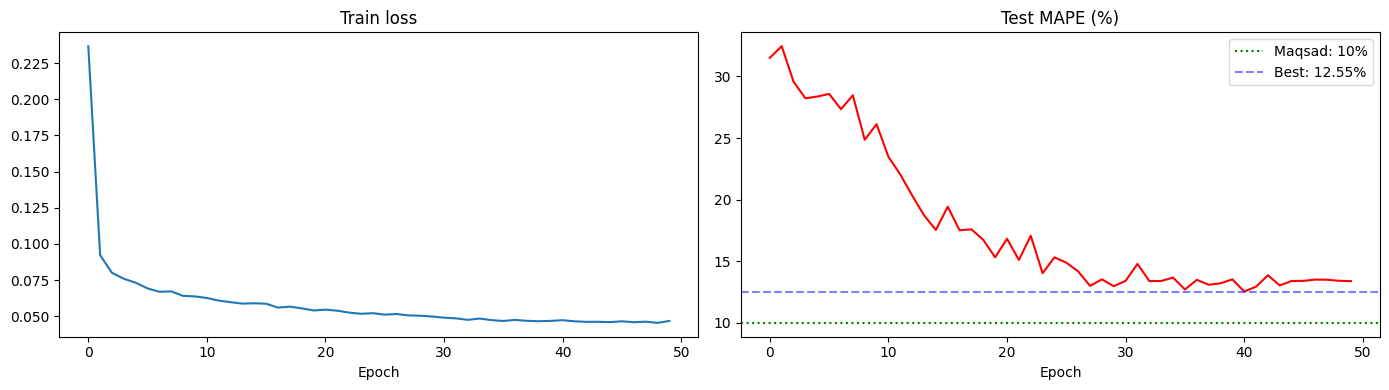

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'])
axes[0].set_title('Train loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(history['test_mape'], color='red')
axes[1].set_title('Test MAPE (%)')
axes[1].axhline(10, color='green', linestyle=':', label='Maqsad: 10%')
axes[1].axhline(best_mape, color='blue', linestyle='--', alpha=0.5, label=f'Best: {best_mape:.2f}%')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test_dev, branch_test_dev).cpu().numpy()

pred_un = balance_scaler.inverse_transform(pred_test.reshape(-1, 1)).reshape(pred_test.shape)
y_un = balance_scaler.inverse_transform(y_test_np.reshape(-1, 1)).reshape(y_test_np.shape)

lstm_metrics = []
for i, bid in enumerate(branch_test.numpy()):
    branch_id = bid + 1
    mape_b = mean_absolute_percentage_error(y_un[i], pred_un[i]) * 100
    rmse_b = np.sqrt(mean_squared_error(y_un[i], pred_un[i]))
    lstm_metrics.append({'branch_id': branch_id, 'mape': mape_b, 'rmse_mln': rmse_b / 1e6})

lstm_metrics_df = pd.DataFrame(lstm_metrics).sort_values('branch_id').reset_index(drop=True)
print(f"O'rtacha MAPE: {lstm_metrics_df['mape'].mean():.2f}%")
print(f"10% dan past: {(lstm_metrics_df['mape'] < 10).sum()}/{len(lstm_metrics_df)}")
print(lstm_metrics_df.to_string(index=False))

O'rtacha MAPE: 12.55%
10% dan past: 9/20
 branch_id      mape   rmse_mln
         1  9.759134  95.943389
         2  6.290444  34.185814
         3  4.296613  20.250637
         4  7.122797  38.382572
         5 11.383103  41.449227
         6 19.646086  49.801019
         7 16.542777 127.222725
         8 19.821118  51.438517
         9  6.493793  36.447242
        10 19.997928  41.123835
        11  6.343158  33.635153
        12  5.476947  27.628956
        13  8.009352  43.784569
        14 15.185027  41.571289
        15  7.417081  34.160850
        16 22.093439  54.820906
        17 18.300070  48.357336
        18 11.177067  44.301689
        19 17.925511  35.769319
        20 17.668243  40.329490


Prophet o'rtacha: 7.88%
LSTM o'rtacha:    12.55%

Prophet g'olib: 15
LSTM g'olib:    5


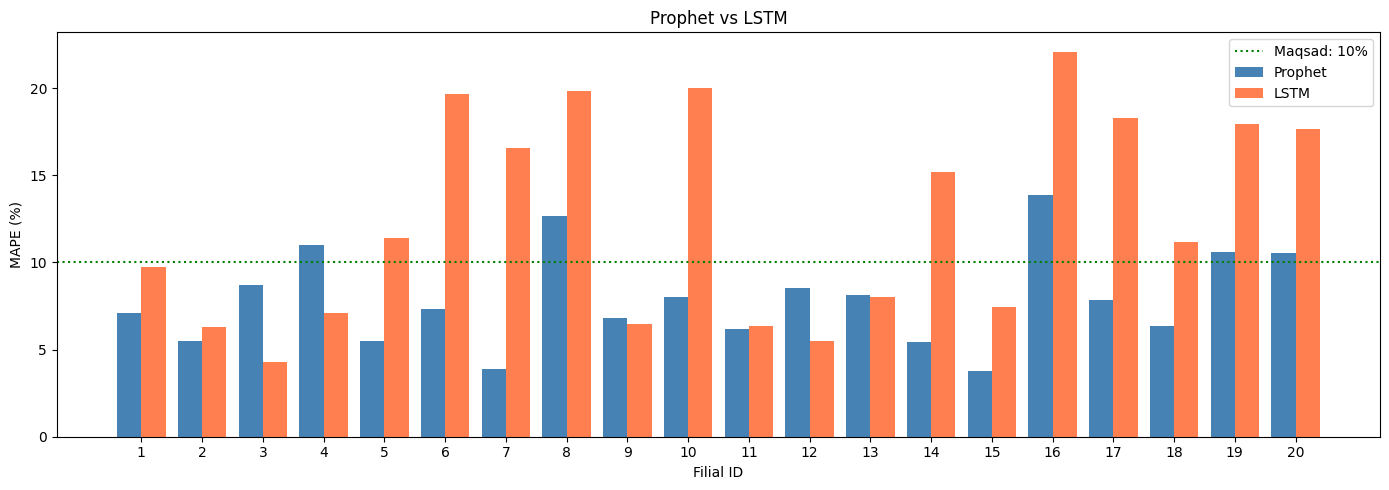

In [11]:
prophet_metrics = pd.read_csv('../models/prophet_metrics.csv')
compare = prophet_metrics[['branch_id', 'mape']].merge(
    lstm_metrics_df[['branch_id', 'mape']], on='branch_id', suffixes=('_prophet', '_lstm'))
compare['best'] = compare.apply(
    lambda r: 'Prophet' if r['mape_prophet'] < r['mape_lstm'] else 'LSTM', axis=1)

print(f"Prophet o'rtacha: {compare['mape_prophet'].mean():.2f}%")
print(f"LSTM o'rtacha:    {compare['mape_lstm'].mean():.2f}%")
print(f"\nProphet g'olib: {(compare['best'] == 'Prophet').sum()}")
print(f"LSTM g'olib:    {(compare['best'] == 'LSTM').sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(compare))
w = 0.4
ax.bar(x - w/2, compare['mape_prophet'], w, label='Prophet', color='steelblue')
ax.bar(x + w/2, compare['mape_lstm'], w, label='LSTM', color='coral')
ax.axhline(10, color='green', linestyle=':', label='Maqsad: 10%')
ax.set_xticks(x)
ax.set_xticklabels(compare['branch_id'])
ax.set_xlabel('Filial ID')
ax.set_ylabel('MAPE (%)')
ax.set_title('Prophet vs LSTM')
ax.legend()
plt.tight_layout()
plt.show()

## Ensemble (Prophet + LSTM o'rtachasi)

In [12]:
import pickle
with open('../models/prophet_models.pkl', 'rb') as f:
    prophet_models = pickle.load(f)

# Prophet'dan har filial uchun forecast
ensemble_metrics = []
for i, bid_idx in enumerate(branch_test.numpy()):
    branch_id = bid_idx + 1
    
    # LSTM forecast (allaqachon)
    lstm_pred = pred_un[i]
    
    # Prophet forecast - shu davr uchun
    pm = prophet_models[branch_id]
    last_train_date = pd.to_datetime(train_data[train_data['branch_id'] == branch_id]['date'].max())
    future_dates = pd.bdate_range(start=last_train_date + pd.Timedelta(days=1), periods=PRED_LEN + 5)
    history_dates = pd.bdate_range(end=last_train_date, periods=500)
    all_d = pd.DatetimeIndex(list(history_dates) + list(future_dates)).drop_duplicates().sort_values()
    future = pd.DataFrame({'ds': all_d})
    future['is_payday'] = future['ds'].dt.day.isin(list(range(1, 6)) + list(range(25, 31))).astype(int)
    fcst = pm.predict(future)
    prophet_pred = fcst[fcst['ds'] > last_train_date]['yhat'].values[:PRED_LEN]
    
    # Ensemble: o'rtacha
    ensemble_pred = (lstm_pred + prophet_pred) / 2
    
    actual = y_un[i]
    mape_e = mean_absolute_percentage_error(actual, ensemble_pred) * 100
    ensemble_metrics.append({'branch_id': branch_id, 'mape': mape_e})

ensemble_df = pd.DataFrame(ensemble_metrics)
print(f"Prophet:  {compare['mape_prophet'].mean():.2f}%")
print(f"LSTM:     {compare['mape_lstm'].mean():.2f}%")
print(f"Ensemble: {ensemble_df['mape'].mean():.2f}%")
print(f"\nEnsemble 10% dan past: {(ensemble_df['mape'] < 10).sum()}/{len(ensemble_df)}")

Importing plotly failed. Interactive plots will not work.


Prophet:  7.88%
LSTM:     12.55%
Ensemble: 9.13%

Ensemble 10% dan past: 12/20


In [13]:
import pickle

torch.save({
    'model_state': model.state_dict(),
    'config': {
        'input_size': INPUT_SIZE,
        'hidden': HIDDEN,
        'num_branches': NUM_BRANCHES,
        'emb_dim': EMB_DIM,
        'pred_len': PRED_LEN,
        'seq_len': SEQ_LEN,
        'features': FEATURES,
    },
}, '../models/lstm_model.pth')

with open('../models/scalers.pkl', 'wb') as f:
    pickle.dump({'balance_scaler': balance_scaler, 'feature_scaler': feature_scaler}, f)

lstm_metrics_df.to_csv('../models/lstm_metrics.csv', index=False)
ensemble_df.to_csv('../models/ensemble_metrics.csv', index=False)
print('Saqlandi')

Saqlandi
